In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load historical data
df = pd.read_csv("../data/tech_fpa_data.csv")

print(df)


   Year  Revenue  Operating_Margin  Operating_Expense  Net_Income
0  2021   257637              0.31             177000       76033
1  2022   282836              0.29             200000       59972
2  2023   307394              0.30             218000       73795
3  2024   328284              0.32             223000      100118


In [5]:
# Scenario assumptions
last_revenue = df.loc[df["Year"] == 2024, "Revenue"].values[0]
last_margin = df.loc[df["Year"] == 2024, "Operating_Margin"].values[0]

years = [2025, 2026, 2027]

scenarios = {
    "Base": {"growth": 0.08, "margin": 0.32},
    "Optimistic": {"growth": 0.12, "margin": 0.34},
    "Downside": {"growth": 0.04, "margin": 0.29}
}

results = []

for scenario_name, assumptions in scenarios.items():
    revenue = last_revenue
    for year in years:
        revenue = revenue * (1 + assumptions["growth"])
        operating_income = revenue * assumptions["margin"]
        net_income = operating_income * 0.75  # simple net income assumption

        results.append({
            "Scenario": scenario_name,
            "Year": year,
            "Projected_Revenue": revenue,
            "Projected_Operating_Income": operating_income,
            "Projected_Net_Income": net_income
        })

scenario_df = pd.DataFrame(results)
print(scenario_df)

     Scenario  Year  Projected_Revenue  Projected_Operating_Income  \
0        Base  2025      354546.720000               113454.950400   
1        Base  2026      382910.457600               122531.346432   
2        Base  2027      413543.294208               132333.854147   
3  Optimistic  2025      367678.080000               125010.547200   
4  Optimistic  2026      411799.449600               140011.812864   
5  Optimistic  2027      461215.383552               156813.230408   
6    Downside  2025      341415.360000                99010.454400   
7    Downside  2026      355071.974400               102970.872576   
8    Downside  2027      369274.853376               107089.707479   

   Projected_Net_Income  
0          85091.212800  
1          91898.509824  
2          99250.390610  
3          93757.910400  
4         105008.859648  
5         117609.922806  
6          74257.840800  
7          77228.154432  
8          80317.280609  


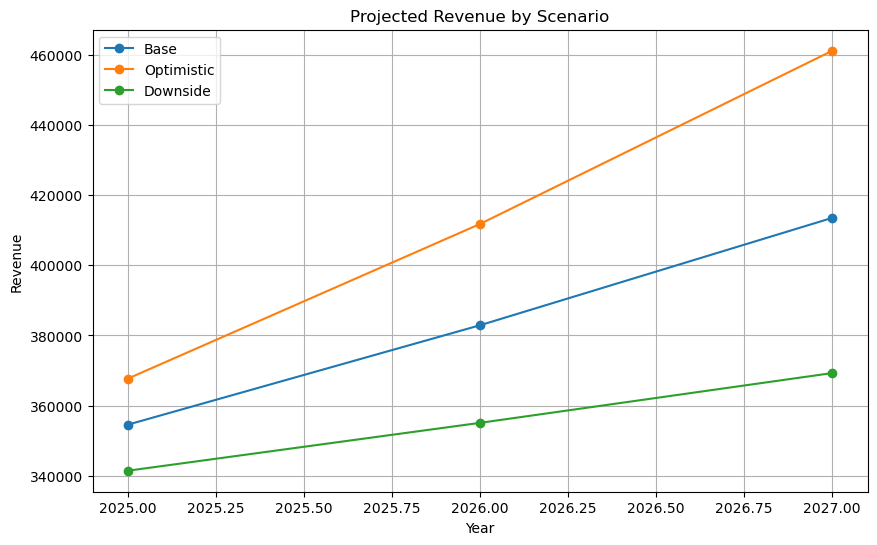

In [6]:
plt.figure(figsize=(10,6))

for scenario in scenario_df["Scenario"].unique():
    temp = scenario_df[scenario_df["Scenario"] == scenario]
    plt.plot(temp["Year"], temp["Projected_Revenue"], marker="o", label=scenario)

plt.title("Projected Revenue by Scenario")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.savefig("revenue_scenarios.png", bbox_inches="tight")
plt.show()

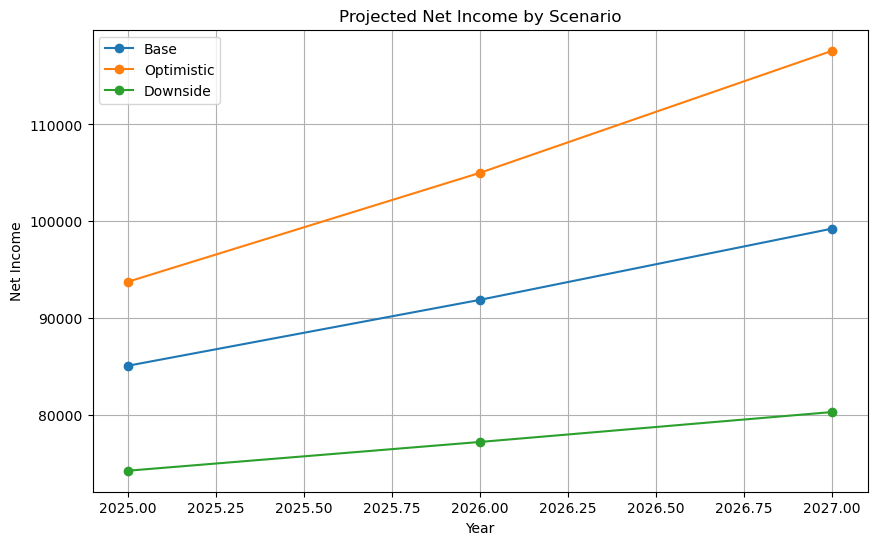

In [7]:
plt.figure(figsize=(10,6))

for scenario in scenario_df["Scenario"].unique():
    temp = scenario_df[scenario_df["Scenario"] == scenario]
    plt.plot(temp["Year"], temp["Projected_Net_Income"], marker="o", label=scenario)

plt.title("Projected Net Income by Scenario")
plt.xlabel("Year")
plt.ylabel("Net Income")
plt.legend()
plt.grid(True)

plt.savefig("net_income_scenarios.png", bbox_inches="tight")
plt.show()